In [1]:
# %%
from sklearn.datasets import make_classification
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss, mean_squared_error
from sklearn.base import BaseEstimator, ClassifierMixin
from scipy.optimize import minimize

In [2]:
# generate dataset
X, y = make_classification(
    n_samples=200,      # number of samples
    n_features=2,       # two features
    n_informative=2,    # both features are informative
    n_redundant=0,      # no redundant features
    n_clusters_per_class=1,
    random_state=42
)

# put into DataFrame
df = pd.DataFrame(X, columns=["feature1", "feature2"])
df["class"] = y

df.head()


,feature1,feature2,class
0,-0.872929,0.013042,1
1,1.312935,2.770534,1
2,2.340428,2.420996,1
3,2.294548,-0.404380,1
4,0.944105,0.477241,1


In [3]:
# %%
# --- Model 1: Logistic Regression with Log Loss (default) ---
log_reg_ce = LogisticRegression(solver="lbfgs")
log_reg_ce.fit(X, y)
y_pred_ce = log_reg_ce.predict(X)
y_proba_ce = log_reg_ce.predict_proba(X)[:, 1]

acc_ce = accuracy_score(y, y_pred_ce)
loss_ce = log_loss(y, y_proba_ce)

print("Cross-Entropy Logistic Regression")
print("Accuracy:", acc_ce)
print("Log Loss:", loss_ce)

Cross-Entropy Logistic Regression
Accuracy: 0.84
Log Loss: 0.366546409992675


In [4]:
# %%
# --- Model 2: Logistic Regression with MSE (custom) ---

class LogisticRegressionMSE(BaseEstimator, ClassifierMixin):
    def __init__(self):
        self.w = None
    
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    def fit(self, X, y):
        Xb = np.hstack([np.ones((X.shape[0], 1)), X])  # bias term
        
        def mse_loss(w):
            preds = self.sigmoid(Xb @ w)
            return mean_squared_error(y, preds)
        
        res = minimize(mse_loss, np.zeros(Xb.shape[1]))
        self.w = res.x
        return self
    
    def predict_proba(self, X):
        Xb = np.hstack([np.ones((X.shape[0], 1)), X])
        probs = self.sigmoid(Xb @ self.w)
        return np.vstack([1 - probs, probs]).T
    
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

In [5]:
# Train custom MSE logistic regression
log_reg_mse = LogisticRegressionMSE()
log_reg_mse.fit(X, y)
y_pred_mse = log_reg_mse.predict(X)
y_proba_mse = log_reg_mse.predict_proba(X)[:, 1]

acc_mse = accuracy_score(y, y_pred_mse)
loss_mse = mean_squared_error(y, y_proba_mse)

print("\nMSE Logistic Regression")
print("Accuracy:", acc_mse)
print("MSE Loss:", loss_mse)


MSE Logistic Regression
Accuracy: 0.835
MSE Loss: 0.11101832502950497


In [6]:
# %%
# --- Decision Boundary Plot Function ---
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", cmap=plt.cm.coolwarm)
    plt.title(title)
    plt.show()

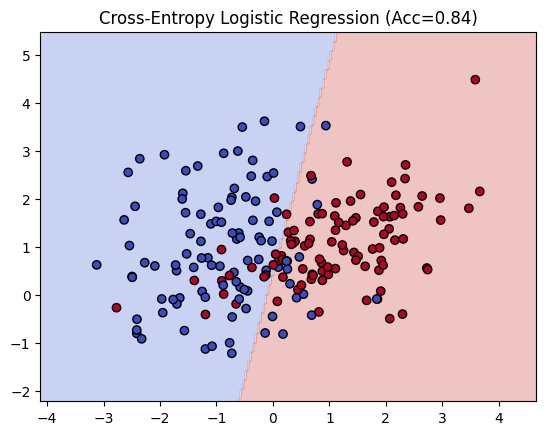

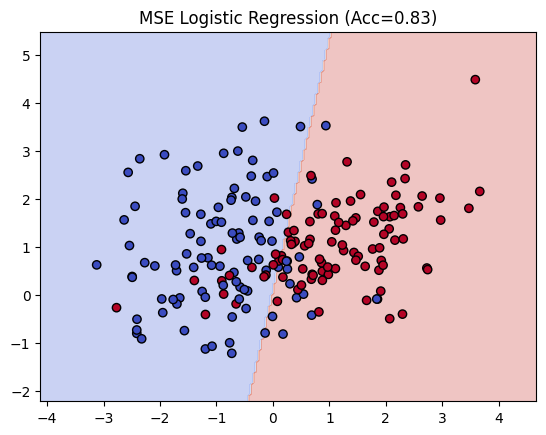

In [7]:
# Plot decision boundaries
plot_decision_boundary(log_reg_ce, X, y, f"Cross-Entropy Logistic Regression (Acc={acc_ce:.2f})")
plot_decision_boundary(log_reg_mse, X, y, f"MSE Logistic Regression (Acc={acc_mse:.2f})")